<a href="https://colab.research.google.com/github/MdShajalalsojib/Data-Mining-Lab/blob/main/Lab_Report_003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

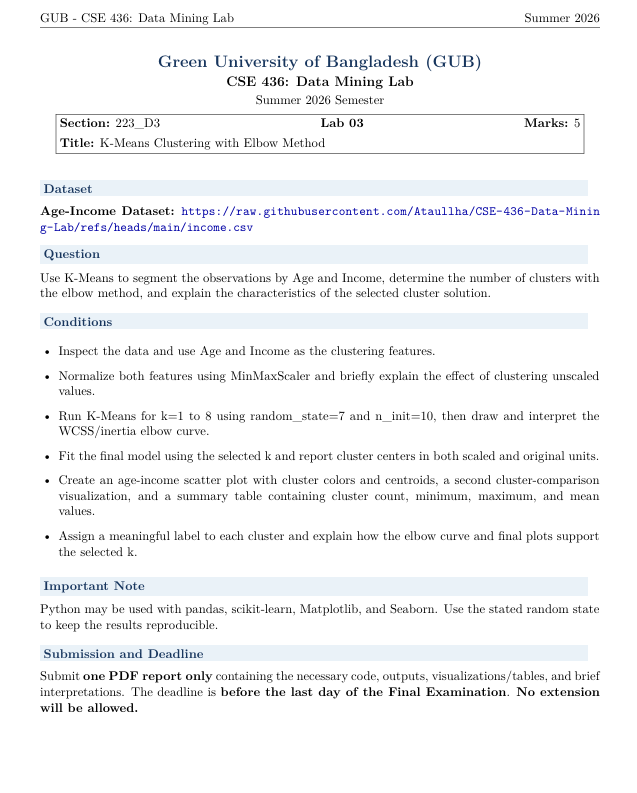

DATASET INFORMATION
      Name  Age  Income($)
0      Rob   27      70000
1  Michael   29      90000
2    Mohan   29      61000
3   Ismail   28      60000
4     Kory   42     150000

Dataset Shape: (22, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes
None

Missing Values:
Age          0
Income($)    0
dtype: int64

SCALED FEATURES
        Age  Income($)
0  0.058824   0.213675
1  0.176471   0.384615
2  0.176471   0.136752
3  0.117647   0.128205
4  0.941176   0.897436

Without scaling, Income would have a much larger numerical
range than Age and could dominate the K-Means distance calculation.


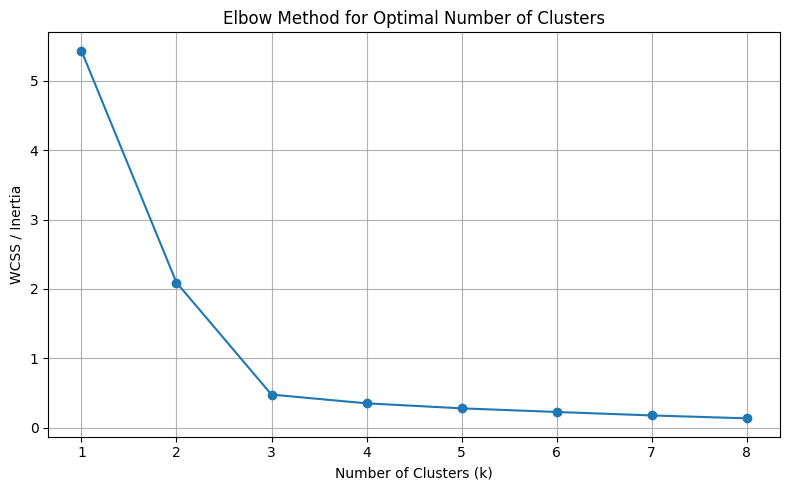


SELECTED NUMBER OF CLUSTERS
Optimal number of clusters: 3

CLUSTER CENTERS - SCALED UNITS
        Age  Income($)
0  0.137255   0.116334
1  0.722689   0.897436
2  0.852941   0.202279

CLUSTER CENTERS - ORIGINAL UNITS
         Age      Income($)
0  28.333333   58611.111111
1  38.285714  150000.000000
2  40.500000   68666.666667


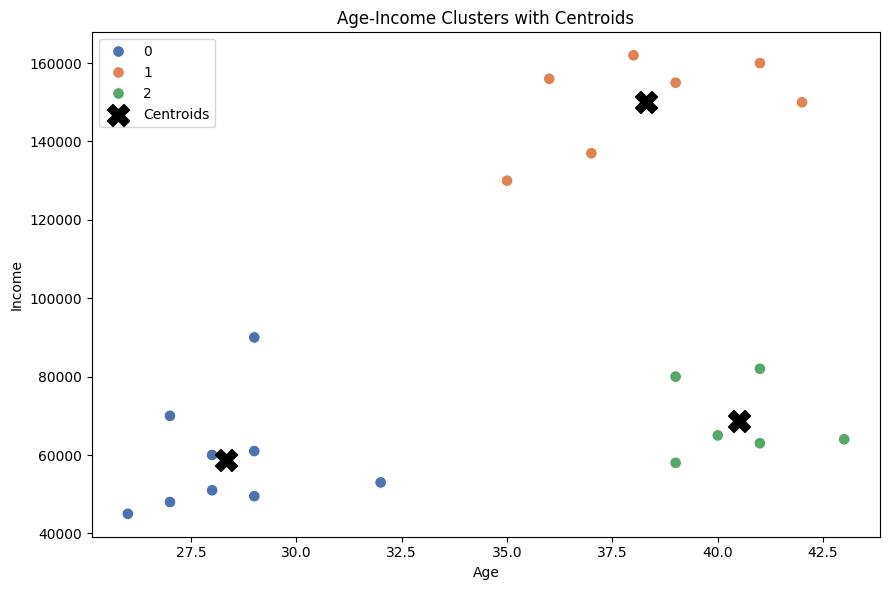

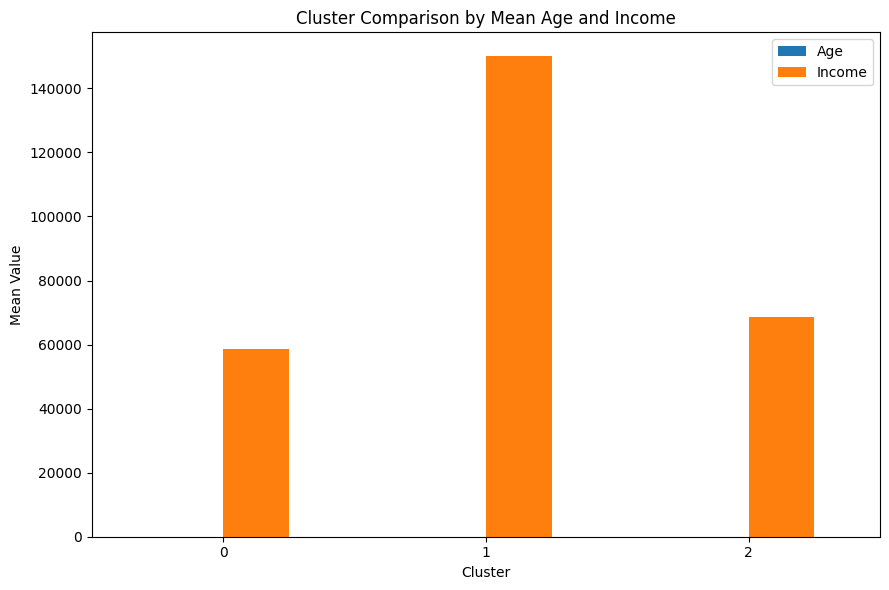


CLUSTER SUMMARY
 Cluster Cluster Label  Count  Age_Min  Age_Max  Age_Mean  Income_Min  Income_Max  Income_Mean
       0    Low Income      9       26       32     28.33       45000       90000     58611.11
       2 Middle Income      6       39       43     40.50       58000       82000     68666.67
       1   High Income      7       35       42     38.29      130000      162000    150000.00

CLUSTER CHARACTERISTICS

Cluster 0 - Low Income
Age: 26 to 32, Mean = 28.33
Income: 45000 to 90000, Mean = 58611.11

Cluster 2 - Middle Income
Age: 39 to 43, Mean = 40.50
Income: 58000 to 82000, Mean = 68666.67

Cluster 1 - High Income
Age: 35 to 42, Mean = 38.29
Income: 130000 to 162000, Mean = 150000.00

WCSS / INERTIA VALUES
k = 1: 5.4340
k = 2: 2.0911
k = 3: 0.4751
k = 4: 0.3491
k = 5: 0.2769
k = 6: 0.2244
k = 7: 0.1746
k = 8: 0.1327


In [2]:
# ============================================================
# K-MEANS CLUSTERING: AGE-INCOME DATASET
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans


# ============================================================
# 1. Load and Inspect the Dataset
# ============================================================

URL = "https://raw.githubusercontent.com/Ataullha/CSE-436-Data-Mining-Lab/refs/heads/main/income.csv"

df = pd.read_csv(URL)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())
print("\nMissing Values:")
print(df[["Age", "Income($)"]].isnull().sum())


# ============================================================
# 2. Select Age and Income Features
# ============================================================

X = df[["Age", "Income($)"]].copy()


# ============================================================
# 3. Normalize Features using MinMaxScaler
# ============================================================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("\n" + "=" * 60)
print("SCALED FEATURES")
print("=" * 60)

print(pd.DataFrame(
    X_scaled,
    columns=["Age", "Income($)"]
).head())

print("\nWithout scaling, Income would have a much larger numerical")
print("range than Age and could dominate the K-Means distance calculation.")


# ============================================================
# 4. Find WCSS for k = 1 to 8
# ============================================================

wcss = []

for k in range(1, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


# ============================================================
# 5. Elbow Method
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 9),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.xticks(range(1, 9))
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Select the Suitable Number of Clusters
# ============================================================

# Based on the elbow curve
optimal_k = 3

print("\n" + "=" * 60)
print("SELECTED NUMBER OF CLUSTERS")
print("=" * 60)

print("Optimal number of clusters:", optimal_k)


# ============================================================
# 7. Train Final K-Means Model
# ============================================================

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=7,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(X_scaled)


# ============================================================
# 8. Cluster Centers in Scaled Units
# ============================================================

scaled_centers = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=["Age", "Income($)"]
)

print("\n" + "=" * 60)
print("CLUSTER CENTERS - SCALED UNITS")
print("=" * 60)

print(scaled_centers)


# ============================================================
# 9. Cluster Centers in Original Units
# ============================================================

original_centers = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

original_centers = pd.DataFrame(
    original_centers,
    columns=["Age", "Income($)"]
)

print("\n" + "=" * 60)
print("CLUSTER CENTERS - ORIGINAL UNITS")
print("=" * 60)

print(original_centers)


# ============================================================
# 10. Age-Income Scatter Plot with Centroids
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Income($)",
    hue="Cluster",
    palette="deep",
    s=70
)

plt.scatter(
    original_centers["Age"],
    original_centers["Income($)"],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

plt.title("Age-Income Clusters with Centroids")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 11. Cluster Comparison Visualization
# ============================================================

cluster_means = df.groupby("Cluster")[["Age", "Income($)"]].mean()

cluster_means.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Cluster Comparison by Mean Age and Income")
plt.xlabel("Cluster")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(["Age", "Income"])

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary Table
# ============================================================

summary = df.groupby("Cluster").agg(
    Count=("Cluster", "size"),
    Age_Min=("Age", "min"),
    Age_Max=("Age", "max"),
    Age_Mean=("Age", "mean"),
    Income_Min=("Income($)", "min"),
    Income_Max=("Income($)", "max"),
    Income_Mean=("Income($)", "mean")
).reset_index()


# ============================================================
# 13. Assign Meaningful Cluster Labels
# ============================================================

income_order = (
    summary
    .sort_values("Income_Mean")
    ["Cluster"]
    .tolist()
)

labels = [
    "Low Income",
    "Middle Income",
    "High Income"
]

cluster_labels = dict(
    zip(income_order, labels)
)

df["Cluster Label"] = df["Cluster"].map(cluster_labels)

summary["Cluster Label"] = summary["Cluster"].map(cluster_labels)

summary = summary.sort_values("Income_Mean")


# ============================================================
# 14. Final Summary Table
# ============================================================

print("\n" + "=" * 80)
print("CLUSTER SUMMARY")
print("=" * 80)

print(
    summary[
        [
            "Cluster",
            "Cluster Label",
            "Count",
            "Age_Min",
            "Age_Max",
            "Age_Mean",
            "Income_Min",
            "Income_Max",
            "Income_Mean"
        ]
    ].round(2).to_string(index=False)
)


# ============================================================
# 15. Final Cluster Characteristics
# ============================================================

print("\n" + "=" * 70)
print("CLUSTER CHARACTERISTICS")
print("=" * 70)

for _, row in summary.iterrows():

    print(
        f"\nCluster {int(row['Cluster'])} - {row['Cluster Label']}"
    )

    print(
        f"Age: {row['Age_Min']:.0f} to {row['Age_Max']:.0f}, "
        f"Mean = {row['Age_Mean']:.2f}"
    )

    print(
        f"Income: {row['Income_Min']:.0f} to {row['Income_Max']:.0f}, "
        f"Mean = {row['Income_Mean']:.2f}"
    )


# ============================================================
# 16. WCSS Values
# ============================================================

print("\n" + "=" * 60)
print("WCSS / INERTIA VALUES")
print("=" * 60)

for k, value in zip(range(1, 9), wcss):

    print(f"k = {k}: {value:.4f}")

# **Update Code**

# **Loading the Dataset**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

URL = "https://raw.githubusercontent.com/Ataullha/CSE-436-Data-Mining-Lab/refs/heads/main/income.csv"

df = pd.read_csv(URL)

print("Loading the Dataset")
print(df.head())
print("\nShape:", df.shape)

Loading the Dataset
      Name  Age  Income($)
0      Rob   27      70000
1  Michael   29      90000
2    Mohan   29      61000
3   Ismail   28      60000
4     Kory   42     150000

Shape: (22, 3)


# **Selecting and Normalizing Features**

In [5]:
print("\nSelecting and Normalizing Features")

X = df[["Age", "Income($)"]]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(pd.DataFrame(
    X_scaled,
    columns=["Age", "Income($)"]
).head())



Selecting and Normalizing Features
        Age  Income($)
0  0.058824   0.213675
1  0.176471   0.384615
2  0.176471   0.136752
3  0.117647   0.128205
4  0.941176   0.897436


# **Finding the Elbow**


Finding the Elbow


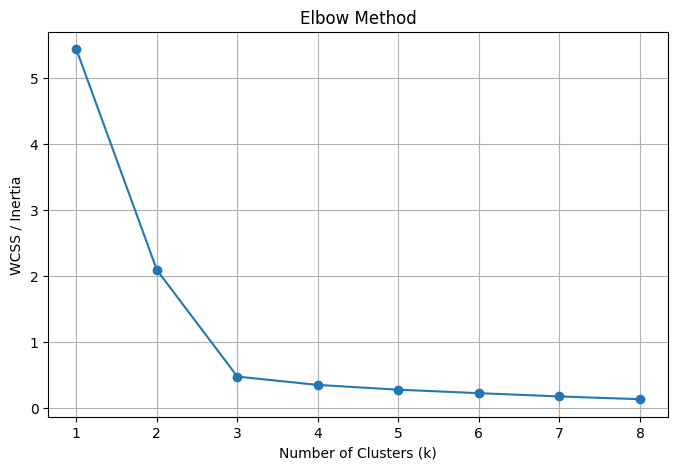

In [6]:
print("\nFinding the Elbow")

wcss = []

for k in range(1, 9):
    model = KMeans(
        n_clusters=k,
        random_state=7,
        n_init=10
    )

    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 9),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 9))
plt.grid(True)
plt.show()

# **Final K-Means Model**

In [7]:
print("\nFinal K-Means Model")

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=7,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())


Final K-Means Model
      Name  Age  Income($)  Cluster
0      Rob   27      70000        0
1  Michael   29      90000        0
2    Mohan   29      61000        0
3   Ismail   28      60000        0
4     Kory   42     150000        1


# **Cluster Centers**

In [8]:
print("\nCluster Centers")

# Scaled centers
scaled_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Age", "Income($)"]
)

print("\nScaled Cluster Centers:")
print(scaled_centers.round(3))

# Original centers
original_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

original_centers = pd.DataFrame(
    original_centers,
    columns=["Age", "Income($)"]
)

print("\nOriginal Cluster Centers:")
print(original_centers.round(2))


Cluster Centers

Scaled Cluster Centers:
     Age  Income($)
0  0.137      0.116
1  0.723      0.897
2  0.853      0.202

Original Cluster Centers:
     Age  Income($)
0  28.33   58611.11
1  38.29  150000.00
2  40.50   68666.67


# **Comparison of Cluster Mean Values**

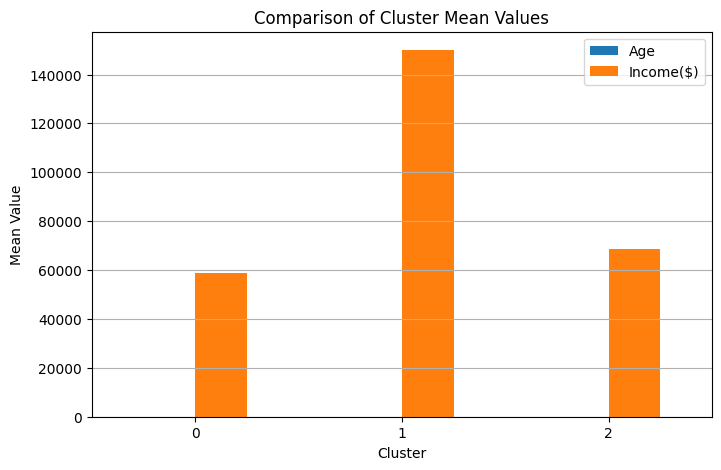

In [14]:
cluster_mean = df.groupby('Cluster')[['Age', 'Income($)']].mean()

cluster_mean.plot(kind='bar', figsize=(8, 5))

plt.xlabel("Cluster")
plt.ylabel("Mean Value")
plt.title("Comparison of Cluster Mean Values")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# **Cluster Summary**

In [11]:
print("\nCluster Summary")

summary = df.groupby("Cluster").agg(
    Count=("Cluster", "size"),
    Age_Min=("Age", "min"),
    Age_Max=("Age", "max"),
    Age_Mean=("Age", "mean"),
    Income_Min=("Income($)", "min"),
    Income_Max=("Income($)", "max"),
    Income_Mean=("Income($)", "mean")
).reset_index()

# Assign meaningful labels according to mean income
order = summary.sort_values("Income_Mean")["Cluster"].tolist()

labels = ["Low Income($)", "Middle Income", "High Income($)"]

label_map = dict(zip(order, labels))

summary["Cluster Label"] = summary["Cluster"].map(label_map)
df["Cluster Label"] = df["Cluster"].map(label_map)

print(
    summary[
        [
            "Cluster",
            "Cluster Label",
            "Count",
            "Age_Min",
            "Age_Max",
            "Age_Mean",
            "Income_Min",
            "Income_Max",
            "Income_Mean"
        ]
    ].round(2).to_string(index=False)
)


Cluster Summary
 Cluster  Cluster Label  Count  Age_Min  Age_Max  Age_Mean  Income_Min  Income_Max  Income_Mean
       0  Low Income($)      9       26       32     28.33       45000       90000     58611.11
       1 High Income($)      7       35       42     38.29      130000      162000    150000.00
       2  Middle Income      6       39       43     40.50       58000       82000     68666.67


# **Cluster Visualization**

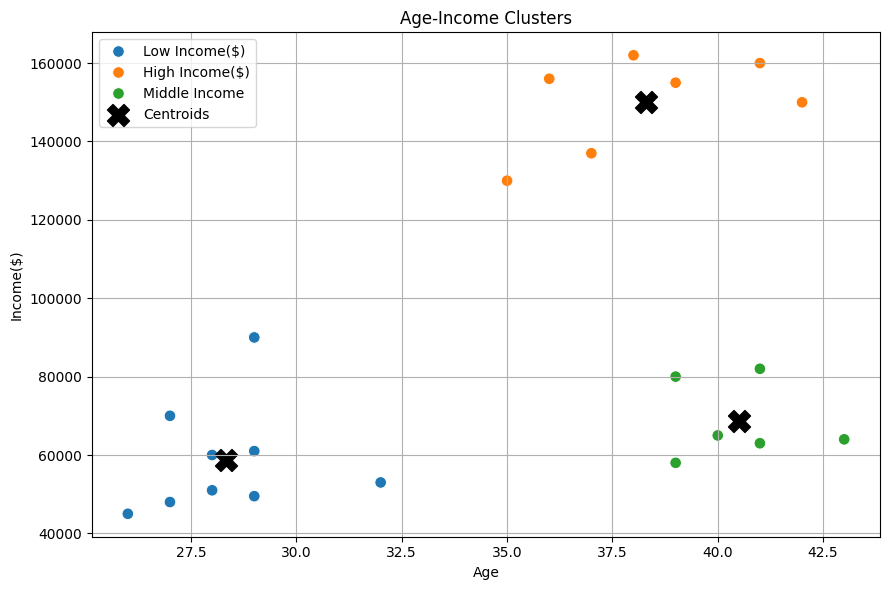

In [12]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Income($)",
    hue="Cluster Label",
    s=70
)

plt.scatter(
    original_centers["Age"],
    original_centers["Income($)"],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

plt.title("Age-Income Clusters")
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()